LIBRARIES

In [6]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

INPUTS

In [7]:
IMG_HEIGHT=224
IMG_WIDTH =224
IMG_CHANNELS = 3
CLASS_NAMES =["lilly", "lotus", "orchid", "sunflower", "tulip"]

In [8]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    r"C:\My Folder\Projects\Computer_Vision\flower_images\train",
    labels = 'inferred',
    label_mode = 'int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size = 16
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    r"C:\My Folder\Projects\Computer_Vision\flower_images\val",
    labels = 'inferred',
    label_mode = 'int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size = 16
)

normalize = tf.keras.layers.Rescaling(1./255)

train_dataset =  train_dataset.map(lambda x, y: (normalize(x), y))
val_dataset =  val_dataset.map(lambda x, y: (normalize(x), y))

Found 3000 files belonging to 5 classes.
Found 1000 files belonging to 5 classes.


NETWORK ARCHITECTURE

In [9]:
model = keras.Sequential([
    keras.layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),

    keras.layers.Conv2D(64, kernel_size=3, strides=1, padding='same', activation='relu'),
    keras.layers.Conv2D(64, kernel_size=3, strides=1, padding='same', activation='relu'),
    keras.layers.MaxPool2D(pool_size=2, strides= 2),

    keras.layers.Conv2D(128, kernel_size=3, strides=1, padding='same', activation='relu'),
    keras.layers.Conv2D(128, kernel_size=3, strides=1, padding='same', activation='relu'),
    keras.layers.MaxPool2D(pool_size=2, strides= 2),

    keras.layers.Conv2D(256, kernel_size=3, strides=1, padding='same', activation='relu'),
    keras.layers.Conv2D(256, kernel_size=3, strides=1, padding='same', activation='relu'),
    keras.layers.Conv2D(256, kernel_size=3, strides=1, padding='same', activation='relu'),
    keras.layers.MaxPool2D(pool_size=2, strides= 2),

    keras.layers.Conv2D(512, kernel_size=3, strides=1, padding='same', activation='relu'),
    keras.layers.Conv2D(512, kernel_size=3, strides=1, padding='same', activation='relu'),
    keras.layers.Conv2D(512, kernel_size=3, strides=1, padding='same', activation='relu'),
    keras.layers.MaxPool2D(pool_size=2, strides= 2),

    keras.layers.Conv2D(512, kernel_size=3, strides=1, padding='same', activation='relu'),
    keras.layers.Conv2D(512, kernel_size=3, strides=1, padding='same', activation='relu'),
    keras.layers.Conv2D(512, kernel_size=3, strides=1, padding='same', activation='relu'),
    keras.layers.MaxPool2D(pool_size=2, strides= 2),

    keras.layers.Flatten(),

    keras.layers.Dense(4096, activation='relu'),
    keras.layers.Dropout(0.5),

    keras.layers.Dense(4096, activation='relu'),
    keras.layers.Dropout(0.5),
    
    keras.layers.Dense(len(CLASS_NAMES), activation='softmax')

])

model.compile(
    optimizer ='adam',
    loss= tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │        20,485 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,281,029 (512.24 MB)

 Trainable params: 134,281,029 (512.24 MB)

 Non-trainable params: 0 (0.00 B)

TRAINING

In [10]:
EPOCHS = 5
history =  model.fit(
    train_dataset,
    validation_data= val_dataset,
    epochs=EPOCHS
)

Epoch 1/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 1431s 8s/step - accuracy: 0.1907 - loss: 1.6646 - val_accuracy: 0.2000 - val_loss: 1.6101
Epoch 2/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 1405s 7s/step - accuracy: 0.1883 - loss: 1.6111 - val_accuracy: 0.2000 - val_loss: 1.6097
Epoch 3/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 1400s 7s/step - accuracy: 0.1917 - loss: 1.6102 - val_accuracy: 0.2000 - val_loss: 1.6098
Epoch 4/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 1398s 7s/step - accuracy: 0.1873 - loss: 1.6108 - val_accuracy: 0.2000 - val_loss: 1.6096
Epoch 5/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 1401s 7s/step - accuracy: 0.1877 - loss: 1.6106 - val_accuracy: 0.2000 - val_loss: 1.6096


PLOTTING

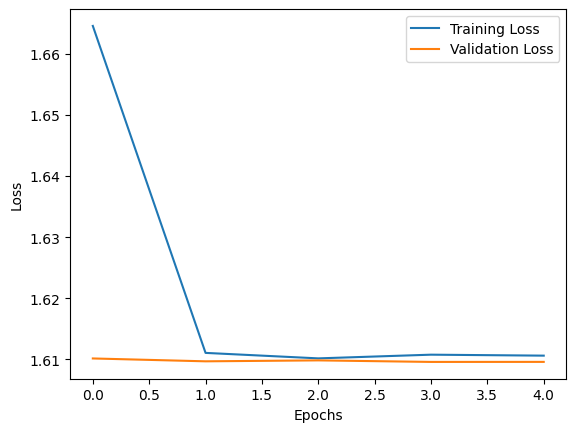

In [11]:
plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

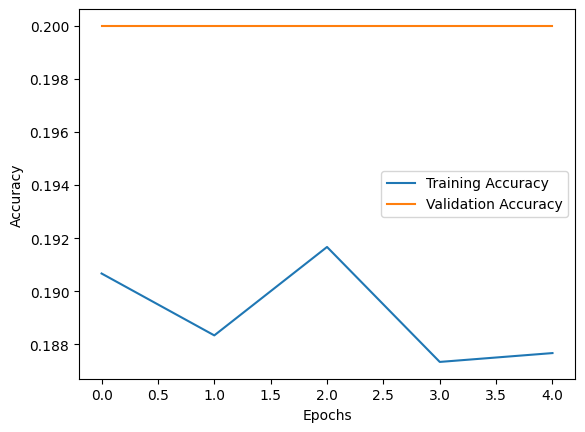

In [12]:
plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()